# SMC-ABC results

In [1]:
import funky.snanawrap as f
from corner import corner
import matplotlib.pyplot as plt
import matplotlib.animation as anime
import numpy as np
import pickle
rng=np.random.default_rng(seed=1)

## Hubble diagrams

Removed /home/ubuntu/SNANA/SNROOT/SIM/prova/prova_SN000052.DAT bc no obs that t1 - t0 > 10.
Removed /home/ubuntu/SNANA/SNROOT/SIM/prova/prova_SN000082.DAT bc no obs that t1 - t0 < 0.


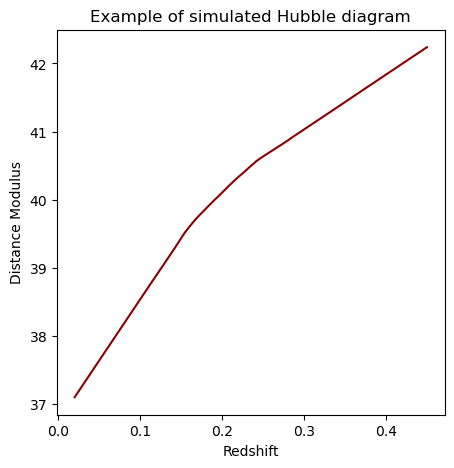

In [16]:
mu, zhd= f.sim_wrapper([0.34,-1],'test')
z_sim,mu_sim=(f.smoother(zhd,mu))
plt.figure(figsize=(5,5))

plt.plot(z_sim,mu_sim,c='darkred')
plt.title('Example of simulated Hubble diagram')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

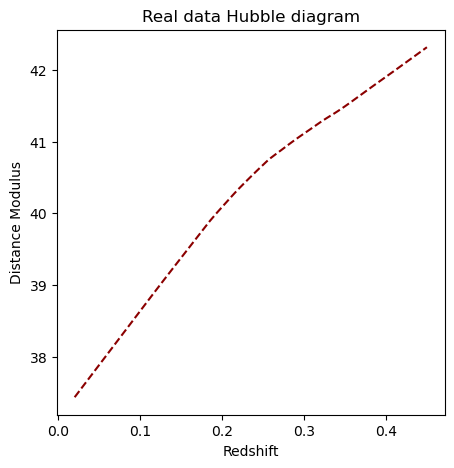

In [21]:
mu_data,z_data=f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
# summary statistic of real data
z_data,mu_data=(f.smoother(z_data,mu_data))
plt.figure(figsize=(5,5))
plt.plot(z_data,mu_data,c='darkred',ls='dashed')
plt.title('Real data Hubble diagram')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

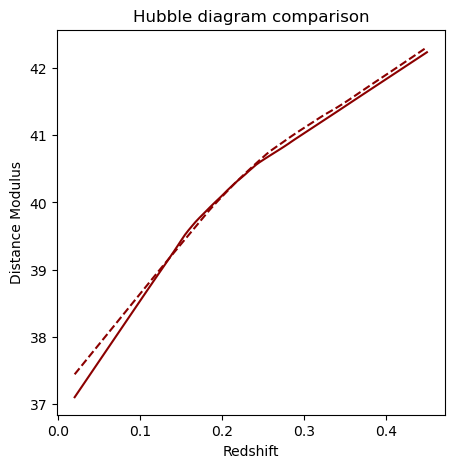

In [22]:
plt.figure(figsize=(5,5))
plt.plot(z_data,mu_data,c='darkred',ls='dashed')
plt.plot(z_sim,mu_sim,c='darkred')

plt.title('Hubble diagram comparison')
plt.xlabel('Redshift')
plt.ylabel('Distance Modulus')
plt.show()

## Parameters' space

In [3]:
with open("/home/ubuntu/gioAbc/firstRun/run1.pickle", "rb") as fin: dataLoad = pickle.load(fin)
for key, item in dataLoad.items(): print(key)
    
thetaDraw = dataLoad["theta_history"]
print(len(thetaDraw))

eps
medians
acc_rates
theta_history
tau_history
8


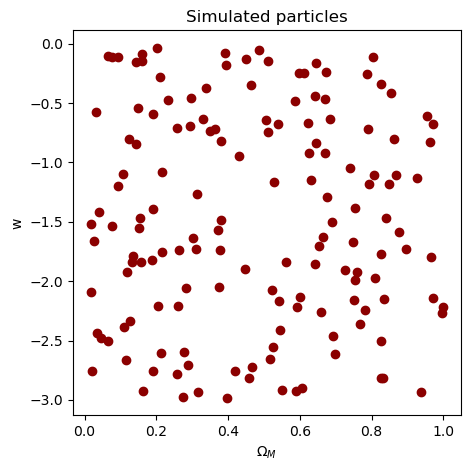

In [6]:
plt.figure(figsize=(5,5))
plt.scatter(thetaDraw[0][:, 0], thetaDraw[0][:, 1], c='darkred')
plt.title('Simulated particles')
plt.xlabel(r'$\Omega_M$')
plt.ylabel('w')
plt.show()

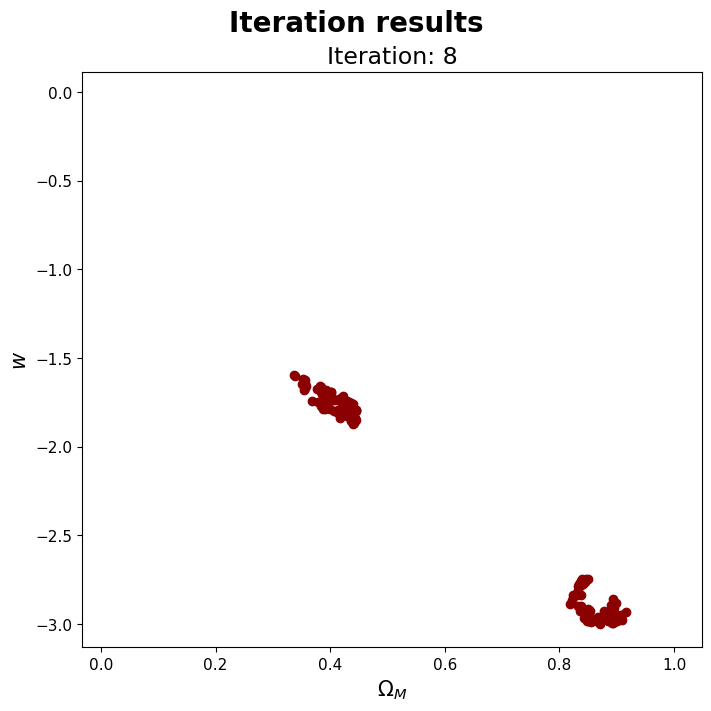

In [15]:
fig, ax = plt.subplots(figsize=(7,7), layout="constrained")
fig.suptitle("Iteration results", weight="bold", fontsize=20)
title = ax.set_title("Iteration: 1", fontsize=17)
ax.set_xlabel(r"$\Omega_M$", fontsize=15)
ax.set_ylabel("$w$", fontsize=15)
ax.tick_params(axis="both", which="major", labelsize=11)

scrat = ax.scatter(thetaDraw[0][:, 0], thetaDraw[0][:, 1], c='darkred')

def update(frame):
    scrat.set_offsets(thetaDraw[frame])
    title.set_text(f"Iteration: {frame + 1}")
    return (scrat, title)

ani = anime.FuncAnimation(fig=fig, func=update, frames=len(thetaDraw), interval=700, blit=True)
    
# ani.save(filename='plswrk.gif', writer="pillow")

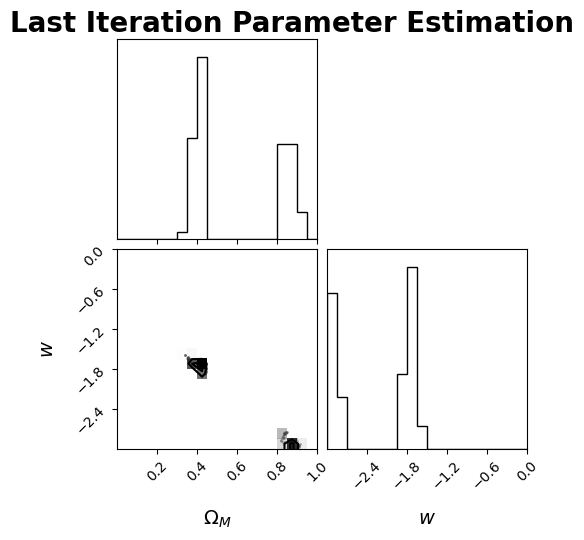

In [5]:
fig = corner(
    thetaDraw[-1], 
    range=[(0, 1), (-3, 0)], 
    labels=[r"$\Omega_M$", r"$w$"],
    title_kwargs={"fontsize": 12},    
    label_kwargs={"fontsize": 14},    
    color="black",                 
    hist_kwargs={"linewidth": 1},   
    hist_bin_factor=1,
    fill_contours=False,               
    plot_datapoints=True,            
    data_kwargs={"alpha": 0.4}
)
fig.suptitle("Last Iteration Parameter Estimation", weight="bold", fontsize=20)
plt.show()